# 🌾🌽🥔🌾🎋 Multi-Crop Disease Detection — Rice + Corn + Potato + Wheat + Sugarcane
**Framework:** TensorFlow / Keras
**Platform:** Google Colab (T4 GPU)
**Model:** EfficientNetB3 (Transfer Learning)
**Classes:** 20 (7 rice + 4 corn + 3 potato + 3 wheat + 3 sugarcane)
**Includes:** Grad-CAM explainability

---
> Runtime → Change runtime type → **T4 GPU** → Save, before running.
> Run cells top to bottom.


## Step 0 — Local environment setup (VS Code specific)
Run this ONCE in your terminal (not in the notebook) to create a virtual environment and
install everything needed. Open a terminal in VS Code (`` Ctrl+` ``) and run:

```bash
python -m venv venv
venv\Scripts\activate
pip install tensorflow scikit-learn matplotlib seaborn pandas pillow
```

Then in VS Code: select this `venv` as your Python interpreter (bottom-right corner, or
`Ctrl+Shift+P` → "Python: Select Interpreter") before running any cells below.

**GPU note:** if your PC doesn't have an NVIDIA GPU, training will be MUCH slower than
Colab's free T4 (hours instead of minutes per phase). Check GPU in the next cell — if it
shows an empty list, training still works, just slowly. Consider reducing `EPOCHS` in
each phase, or using a smaller `IMG_SIZE` (e.g. 180 instead of 224), if training on CPU.


## Step 1 — Check GPU

In [2]:
import sys
print(sys.executable)


c:\Users\Dell\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.21.0
GPU devices: []


## Step 2 — Point directly at your dataset folders (Windows paths)
No Drive mounting needed on local VS Code — just tell Python exactly where your two
datasets sit on your Windows drive. Use **raw strings** (the `r` before the quote) so
backslashes in Windows paths don't cause errors.

Example: if you extracted/downloaded them to your Downloads folder:
```
RICE_SOURCE = r"C:\Users\YourName\Downloads\rice-leaf-disease-riceguard-19k-cleaned"
NEW_CROPS_SOURCE = r"C:\Users\YourName\Downloads\five-crop-diseases-dataset"
```
Both can point at either an already-extracted **folder**, or a **.zip** file — the next
cell handles either case.

In [4]:
# ── EDIT THESE to your actual local paths ───────────────────────────
RICE_SOURCE = r"C:\Users\Dell\Downloads\archive (6).zip"
NEW_CROPS_SOURCE = r"C:\Users\Dell\Downloads\archive (5).zip"
# ─────────────────────────────────────────────────────────────────

print("Rice source     :", RICE_SOURCE)
print("New crops source:", NEW_CROPS_SOURCE)


Rice source     : C:\Users\Dell\Downloads\archive (6).zip
New crops source: C:\Users\Dell\Downloads\archive (5).zip


## Step 3 — Get both datasets onto the Colab local disk
Copies files onto `/content` (much faster to read during training than directly off
Drive) and unzips if needed. If you instead uploaded the datasets straight into Colab's
file browser (left sidebar), skip this cell and just set `RAW_RICE` / `RAW_NEW` in the
next cell to wherever you dropped them (e.g. `/content/my_upload_folder`).

In [5]:
import os, shutil, zipfile
from pathlib import Path

def stage_dataset(source, dest_dir):
    """Copies a folder as-is, or extracts a .zip, into dest_dir on local disk."""
    source = Path(source)
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    if source.is_dir():
        print(f"Copying folder {source} -> {dest_dir} ...")
        shutil.copytree(source, dest_dir, dirs_exist_ok=True)
    elif source.suffix == ".zip":
        print(f"Extracting {source} -> {dest_dir} ...")
        with zipfile.ZipFile(source) as z:
            z.extractall(dest_dir)
    else:
        raise FileNotFoundError(f"Not found or not a folder/.zip: {source}")

    print("Done:", dest_dir)

stage_dataset(RICE_SOURCE, "./raw_rice")
stage_dataset(NEW_CROPS_SOURCE, "./raw_new")

Extracting C:\Users\Dell\Downloads\archive (6).zip -> raw_rice ...
Done: raw_rice
Extracting C:\Users\Dell\Downloads\archive (5).zip -> raw_new ...
Done: raw_new


## Step 4 — Locate folders robustly
(Same as before — works whether Step 3 copied from Drive or you uploaded manually into
`/content`. Just make sure `RAW_RICE` / `RAW_NEW` point at the right root.)
Kaggle zips sometimes nest an extra folder. Instead of hardcoding paths, we search for
the folders we need by name, wherever they landed.

In [6]:
from pathlib import Path

def find_folder(root, target_name):
    """Return the first directory under root whose name matches target_name exactly."""
    root = Path(root)
    if root.name == target_name and root.is_dir():
        return root
    for p in root.rglob("*"):
        if p.is_dir() and p.name == target_name:
            return p
    return None

RAW_RICE = Path("./raw_rice")
RAW_NEW  = Path("./raw_new")

RICE_TRAIN = find_folder(RAW_RICE, "train")
RICE_VAL   = find_folder(RAW_RICE, "val")
RICE_TEST  = find_folder(RAW_RICE, "test")

CORN_DIR      = find_folder(RAW_NEW, "Corn")
POTATO_DIR    = find_folder(RAW_NEW, "Potato")
SUGARCANE_DIR = find_folder(RAW_NEW, "sugarcane")
WHEAT_DIR     = find_folder(RAW_NEW, "Wheat")

print("Rice train:", RICE_TRAIN)
print("Rice val  :", RICE_VAL)
print("Rice test :", RICE_TEST)
print("Corn      :", CORN_DIR)
print("Potato    :", POTATO_DIR)
print("Sugarcane :", SUGARCANE_DIR)
print("Wheat     :", WHEAT_DIR)

assert all([RICE_TRAIN, RICE_VAL, RICE_TEST, CORN_DIR, POTATO_DIR, SUGARCANE_DIR, WHEAT_DIR]), \
    "One or more folders were not found — print the tree below and adjust find_folder() targets."


Rice train: raw_rice\train
Rice val  : raw_rice\val
Rice test : raw_rice\test
Corn      : raw_new\Crop Diseases Dataset\Crop Diseases\Crop___Disease\Corn
Potato    : raw_new\Crop Diseases Dataset\Crop Diseases\Crop___Disease\Potato
Sugarcane : raw_new\Crop Diseases Dataset\Crop Diseases\Crop___Disease\sugarcane
Wheat     : raw_new\Crop Diseases Dataset\Crop Diseases\Crop___Disease\Wheat


In [7]:
# If any assertion above failed, run this to see the actual tree and fix folder names
def print_tree(root, max_depth=3, _depth=0):
    root = Path(root)
    if _depth > max_depth:
        return
    for p in sorted(root.iterdir()):
        if p.is_dir():
            print("  " * _depth + f"[DIR] {p.name}")
            print_tree(p, max_depth, _depth + 1)

# Uncomment to debug:
# print_tree(RAW_NEW)


## Step 5 — Define the unified 20-class taxonomy

In [8]:
CLASS_NAMES = [
    # rice (existing, unchanged)
    "rice_blast", "rice_healthy", "rice_insect", "rice_leaf_folder",
    "rice_scald", "rice_stripes", "rice_tungro",
    # corn
    "corn_common_rust", "corn_gray_leaf_spot", "corn_healthy", "corn_northern_leaf_blight",
    # potato
    "potato_early_blight", "potato_healthy", "potato_late_blight",
    # wheat
    "wheat_brown_rust", "wheat_healthy", "wheat_yellow_rust",
    # sugarcane
    "sugarcane_red_rot", "sugarcane_healthy", "sugarcane_bacterial_blight",
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Total classes: {NUM_CLASSES}")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {i:2d}. {c}")


Total classes: 20
   0. rice_blast
   1. rice_healthy
   2. rice_insect
   3. rice_leaf_folder
   4. rice_scald
   5. rice_stripes
   6. rice_tungro
   7. corn_common_rust
   8. corn_gray_leaf_spot
   9. corn_healthy
  10. corn_northern_leaf_blight
  11. potato_early_blight
  12. potato_healthy
  13. potato_late_blight
  14. wheat_brown_rust
  15. wheat_healthy
  16. wheat_yellow_rust
  17. sugarcane_red_rot
  18. sugarcane_healthy
  19. sugarcane_bacterial_blight


## Step 6 — Build the unified dataset
Copies your rice train/val/test as-is (renamed with `rice_` prefix), and splits the
new crops 80/10/10 into the same structure since they arrive as flat per-class folders.

In [9]:
import shutil, random
from sklearn.model_selection import train_test_split

random.seed(42)
DATASET_ROOT = Path("./dataset")
for split in ["train", "val", "test"]:
    (DATASET_ROOT / split).mkdir(parents=True, exist_ok=True)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

def list_images(folder):
    files = []
    for ext in IMG_EXTS:
        files.extend(Path(folder).glob(f"*{ext}"))
    return files

# ---- 1) Copy rice splits, renaming class folders with rice_ prefix ----
RICE_CLASSES = ["blast", "healthy", "insect", "leaf_folder", "scald", "stripes", "tungro"]
RICE_SPLIT_DIRS = {"train": RICE_TRAIN, "val": RICE_VAL, "test": RICE_TEST}

for split, split_dir in RICE_SPLIT_DIRS.items():
    for cls in RICE_CLASSES:
        src = split_dir / cls
        dst = DATASET_ROOT / split / f"rice_{cls}"
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            for f in list_images(src):
                shutil.copy(f, dst / f.name)
        else:
            print(f"[WARN] rice class folder missing: {src}")

print("Rice classes copied.")

# ---- 2) Split + copy the 4 new crops ----
# (crop_root_dir, disease_subfolder_name) -> destination class name
CROP_MAP = {
    (CORN_DIR, "Corn___Common_Rust"):            "corn_common_rust",
    (CORN_DIR, "Corn___Gray_Leaf_Spot"):         "corn_gray_leaf_spot",
    (CORN_DIR, "Corn___Healthy"):                "corn_healthy",
    (CORN_DIR, "Corn___Northern_Leaf_Blight"):   "corn_northern_leaf_blight",
    (POTATO_DIR, "Potato___Early_Blight"):       "potato_early_blight",
    (POTATO_DIR, "Potato___Healthy"):            "potato_healthy",
    (POTATO_DIR, "Potato___Late_Blight"):        "potato_late_blight",
    (WHEAT_DIR, "Wheat___Brown_Rust"):           "wheat_brown_rust",
    (WHEAT_DIR, "Wheat___Healthy"):              "wheat_healthy",
    (WHEAT_DIR, "Wheat___Yellow_Rust"):          "wheat_yellow_rust",
    (SUGARCANE_DIR, "Red Rot"):                  "sugarcane_red_rot",
    (SUGARCANE_DIR, "Healthy"):                  "sugarcane_healthy",
    (SUGARCANE_DIR, "Bacterial Blight"):         "sugarcane_bacterial_blight",
}

for (crop_dir, disease_subdir), dst_name in CROP_MAP.items():
    src_dir = crop_dir / disease_subdir
    if not src_dir.exists():
        print(f"[WARN] missing: {src_dir}")
        continue
    files = list_images(src_dir)
    if len(files) < 10:
        print(f"[WARN] very few images ({len(files)}) in {src_dir}")

    train_files, temp_files = train_test_split(files, test_size=0.2, random_state=42)
    val_files, test_files   = train_test_split(temp_files, test_size=0.5, random_state=42)

    for split, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
        out_dir = DATASET_ROOT / split / dst_name
        out_dir.mkdir(parents=True, exist_ok=True)
        for f in split_files:
            shutil.copy(f, out_dir / f.name)

print("New crop classes copied and split.")
print("\nDataset merge complete at:", DATASET_ROOT)


Rice classes copied.
New crop classes copied and split.

Dataset merge complete at: dataset


## Step 7 — Verify counts per class

In [10]:
def count_images(split_dir):
    counts = {}
    for cls_dir in sorted(Path(split_dir).iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = len(list_images(cls_dir))
    return counts

train_counts = count_images(DATASET_ROOT / "train")
val_counts   = count_images(DATASET_ROOT / "val")
test_counts  = count_images(DATASET_ROOT / "test")

print(f"{'Class':<28}{'Train':>8}{'Val':>8}{'Test':>8}{'Total':>8}")
print("-" * 60)
for cls in CLASS_NAMES:
    tr, va, te = train_counts.get(cls, 0), val_counts.get(cls, 0), test_counts.get(cls, 0)
    print(f"{cls:<28}{tr:>8}{va:>8}{te:>8}{tr+va+te:>8}")


Class                          Train     Val    Test   Total
------------------------------------------------------------
rice_blast                      7202    1540    1550   10292
rice_healthy                    6458    1382    1388    9228
rice_insect                     3308     708     714    4730
rice_leaf_folder                2664     570     576    3810
rice_scald                       588     126     128     842
rice_stripes                    2916     622     630    4168
rice_tungro                     2830     604     612    4046
corn_common_rust                2300     452     464    3216
corn_gray_leaf_spot              978     192     190    1360
corn_healthy                    2222     442     436    3100
corn_northern_leaf_blight       1904     374     376    2654
potato_early_blight             1930     380     384    2694
potato_healthy                   286      54      60     400
potato_late_blight              1930     380     384    2694
wheat_brown_rust        

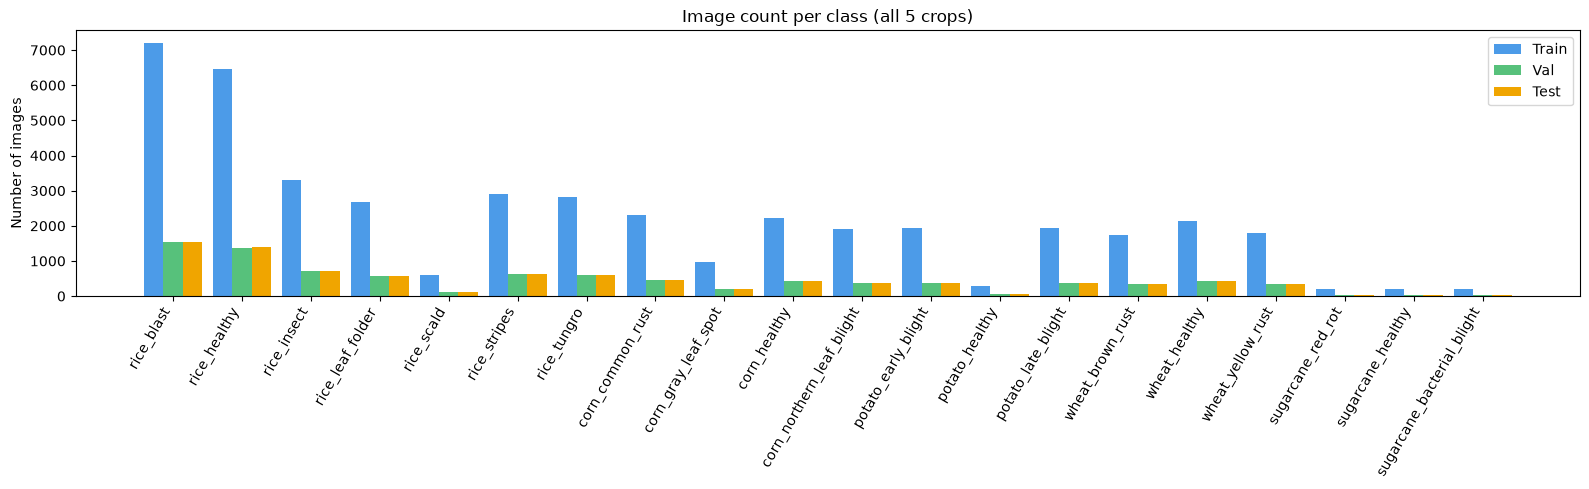

In [11]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(CLASS_NAMES))
w = 0.28
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w, [train_counts.get(c, 0) for c in CLASS_NAMES], w, label="Train", color="#4C9BE8")
ax.bar(x,     [val_counts.get(c, 0)   for c in CLASS_NAMES], w, label="Val",   color="#57C17B")
ax.bar(x + w, [test_counts.get(c, 0)  for c in CLASS_NAMES], w, label="Test",  color="#F0A500")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=60, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Image count per class (all 5 crops)")
ax.legend()
plt.tight_layout()
plt.show()


## Step 8 — Data generators (augmentation)

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 42

train_datagen = ImageDataGenerator(
    rotation_range      = 30,
    horizontal_flip     = True,
    vertical_flip       = True,
    zoom_range          = 0.15,
    width_shift_range   = 0.10,
    height_shift_range  = 0.10,
    shear_range         = 0.10,
    brightness_range    = [0.75, 1.30],
    channel_shift_range = 15.0,
    fill_mode           = "reflect",
)
val_test_datagen = ImageDataGenerator()  # no augmentation, no rescale (EfficientNet does its own preprocessing internally via the base model's expected input; we feed raw 0-255 and let the backbone's own preprocessing layer, if any, handle it — EfficientNetB3 here expects 0-255 as trained on ImageNet with its built-in normalization)

train_gen = train_datagen.flow_from_directory(
    DATASET_ROOT / "train",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = CLASS_NAMES,
    shuffle     = True,
    seed        = SEED,
)
val_gen = val_test_datagen.flow_from_directory(
    DATASET_ROOT / "val",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = CLASS_NAMES,
    shuffle     = False,
)
test_gen = val_test_datagen.flow_from_directory(
    DATASET_ROOT / "test",
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = CLASS_NAMES,
    shuffle     = False,
)


Found 21878 images belonging to 20 classes.
Found 4526 images belonging to 20 classes.
Found 4568 images belonging to 20 classes.


## Step 9 — Class weights (handles imbalance between rice's 19k images and the smaller new-crop classes)

In [13]:
from sklearn.utils.class_weight import compute_class_weight

raw_labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(raw_labels),
    y            = raw_labels,
)
class_weight_dict = dict(enumerate(class_weights_arr))

# Cap extreme weights so training doesn't overreact to very rare classes
CAP = 8.0
class_weight_dict = {k: min(v, CAP) for k, v in class_weight_dict.items()}

print(f"{'Class':<28}{'Images':>8}{'Weight':>8}")
print("-" * 46)
for idx, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<28}{train_counts.get(cls, 0):>8}{class_weight_dict[idx]:>8.3f}")


Class                         Images  Weight
----------------------------------------------
rice_blast                      7202   0.304
rice_healthy                    6458   0.339
rice_insect                     3308   0.661
rice_leaf_folder                2664   0.821
rice_scald                       588   3.721
rice_stripes                    2916   0.750
rice_tungro                     2830   0.773
corn_common_rust                2300   0.951
corn_gray_leaf_spot              978   2.237
corn_healthy                    2222   0.985
corn_northern_leaf_blight       1904   1.149
potato_early_blight             1930   1.134
potato_healthy                   286   7.650
potato_late_blight              1930   1.134
wheat_brown_rust                1732   1.263
wheat_healthy                   2138   1.023
wheat_yellow_rust               1788   1.224
sugarcane_red_rot                194   8.000
sugarcane_healthy                194   8.000
sugarcane_bacterial_blight       194   8.000


## Step 10 — Build the model (EfficientNetB3)

In [14]:
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3

def build_model(num_classes):
    base = EfficientNetB3(
        include_top = False,
        weights     = "imagenet",
        input_shape = (IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = False  # frozen for Phase 1

    inputs = base.input
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

model = build_model(NUM_CLASSES)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,586,883 (44.20 MB)

 Trainable params: 800,276 (3.05 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [1]:
def make_callbacks(phase_name):
    return [
        callbacks.ModelCheckpoint(
            filepath       = f"{phase_name}_best.keras",
            monitor        = "val_accuracy",
            save_best_only = True,
            verbose        = 1,
        ),
        callbacks.EarlyStopping(
            monitor              = "val_accuracy",
            patience             = 8,
            restore_best_weights = True,
            verbose              = 1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = 0.5,
            patience = 3,
            verbose  = 1,
        ),
        callbacks.CSVLogger(f"{phase_name}_log.csv"),
    ]


## Step 11 — Phase 1: train the head, backbone frozen

In [16]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

print("Phase 1: training head only (backbone frozen)")
history1 = model.fit(
    train_gen,
    epochs          = 15,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = make_callbacks("phase1"),
    verbose         = 1,
)


Phase 1: training head only (backbone frozen)
Epoch 1/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.5859 - loss: 1.2654
Epoch 1: val_accuracy improved from None to 0.69642, saving model to phase1_best.keras

Epoch 1: finished saving model to phase1_best.keras
684/684 ━━━━━━━━━━━━━━━━━━━━ 715s 1s/step - accuracy: 0.5859 - loss: 1.2654 - val_accuracy: 0.6964 - val_loss: 0.8432 - learning_rate: 0.0010
Epoch 2/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.6520 - loss: 0.8766
Epoch 2: val_accuracy improved from 0.69642 to 0.72293, saving model to phase1_best.keras

Epoch 2: finished saving model to phase1_best.keras
684/684 ━━━━━━━━━━━━━━━━━━━━ 535s 782ms/step - accuracy: 0.6520 - loss: 0.8766 - val_accuracy: 0.7229 - val_loss: 0.7518 - learning_rate: 0.0010
Epoch 3/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.6663 - loss: 0.7861
Epoch 3: val_accuracy did not improve from 0.72293
684/684 ━━━━━━━━━━━━━━━━━━━━ 532s 777ms/step - accuracy: 0.6663 - los

## Step 12 — Phase 2: unfreeze top layers, fine-tune

In [17]:
model = tf.keras.models.load_model("phase1_best.keras")

FINE_TUNE_FROM = 200
for layer in model.layers:
    layer.trainable = True
for layer in model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Total layers: {len(model.layers)} | Trainable now: {trainable}")

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

print("Phase 2: fine-tuning top layers")
history2 = model.fit(
    train_gen,
    epochs          = 15,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = make_callbacks("phase2"),
    verbose         = 1,
)


Total layers: 390 | Trainable now: 190
Phase 2: fine-tuning top layers
Epoch 1/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7002 - loss: 0.6434
Epoch 1: val_accuracy improved from None to 0.79540, saving model to phase2_best.keras

Epoch 1: finished saving model to phase2_best.keras
684/684 ━━━━━━━━━━━━━━━━━━━━ 825s 1s/step - accuracy: 0.7002 - loss: 0.6434 - val_accuracy: 0.7954 - val_loss: 0.5863 - learning_rate: 1.0000e-04
Epoch 2/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7788 - loss: 0.4314
Epoch 2: val_accuracy improved from 0.79540 to 0.81573, saving model to phase2_best.keras

Epoch 2: finished saving model to phase2_best.keras
684/684 ━━━━━━━━━━━━━━━━━━━━ 808s 1s/step - accuracy: 0.7788 - loss: 0.4314 - val_accuracy: 0.8157 - val_loss: 0.5186 - learning_rate: 1.0000e-04
Epoch 3/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8070 - loss: 0.3590
Epoch 3: val_accuracy improved from 0.81573 to 0.83937, saving model to phase2_best.keras

Epoch 3:

## Step 13 — Phase 3: full fine-tune at low learning rate

In [18]:
model = tf.keras.models.load_model("phase2_best.keras")

for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = "categorical_crossentropy", 
    metrics   = ["accuracy"],
)

print("Phase 3: full fine-tuning")
history3 = model.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = make_callbacks("phase3"),
    verbose         = 1,
)


Phase 3: full fine-tuning
Epoch 1/20
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8161 - loss: 0.3861
Epoch 1: val_accuracy improved from None to 0.87583, saving model to phase3_best.keras

Epoch 1: finished saving model to phase3_best.keras
684/684 ━━━━━━━━━━━━━━━━━━━━ 2285s 3s/step - accuracy: 0.8161 - loss: 0.3861 - val_accuracy: 0.8758 - val_loss: 0.3603 - learning_rate: 1.0000e-05
Epoch 2/20
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8519 - loss: 0.2864
Epoch 2: val_accuracy improved from 0.87583 to 0.89063, saving model to phase3_best.keras

Epoch 2: finished saving model to phase3_best.keras
684/684 ━━━━━━━━━━━━━━━━━━━━ 2252s 3s/step - accuracy: 0.8519 - loss: 0.2864 - val_accuracy: 0.8906 - val_loss: 0.3233 - learning_rate: 1.0000e-05
Epoch 3/20
684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8663 - loss: 0.2396
Epoch 3: val_accuracy improved from 0.89063 to 0.89726, saving model to phase3_best.keras

Epoch 3: finished saving model to phase3_best.keras

## Step 14 — Save the final model

In [2]:
model = tf.keras.models.load_model("phase3_best.keras")

SAVE_PATH = "./multi_crop_disease_model_final.keras"
model.save(SAVE_PATH)
print(f"Model saved to: {SAVE_PATH}")


NameError: name 'tf' is not defined

## Step 15 — Training curves

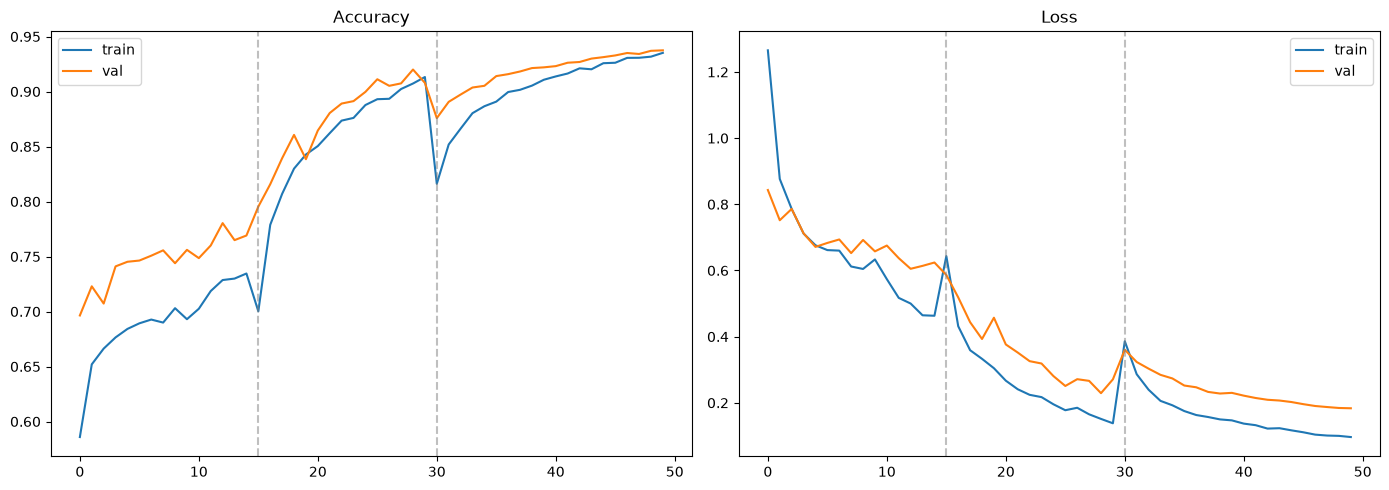

In [20]:
import pandas as pd

phase1_log = pd.read_csv("phase1_log.csv")
phase2_log = pd.read_csv("phase2_log.csv")
phase3_log = pd.read_csv("phase3_log.csv")

acc  = list(phase1_log["accuracy"])     + list(phase2_log["accuracy"])     + list(phase3_log["accuracy"])
vacc = list(phase1_log["val_accuracy"]) + list(phase2_log["val_accuracy"]) + list(phase3_log["val_accuracy"])
loss  = list(phase1_log["loss"])     + list(phase2_log["loss"])     + list(phase3_log["loss"])
vloss = list(phase1_log["val_loss"]) + list(phase2_log["val_loss"]) + list(phase3_log["val_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(acc, label="train"); axes[0].plot(vacc, label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(loss, label="train"); axes[1].plot(vloss, label="val")
axes[1].set_title("Loss"); axes[1].legend()
for ax in axes:
    ax.axvline(len(phase1_log), color="gray", linestyle="--", alpha=0.5)
    ax.axvline(len(phase1_log) + len(phase2_log), color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Step 16 — Evaluate on the test set

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

loss, acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(f"Test Loss    : {loss:.4f}")

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


143/143 ━━━━━━━━━━━━━━━━━━━━ 109s 747ms/step - accuracy: 0.9054 - loss: 0.3053

Test Accuracy: 90.54%
Test Loss    : 0.3053
143/143 ━━━━━━━━━━━━━━━━━━━━ 83s 569ms/step

Classification Report:
                            precision    recall  f1-score   support

                rice_blast       0.93      0.74      0.82       775
              rice_healthy       0.84      0.90      0.87       694
               rice_insect       0.89      0.91      0.90       357
          rice_leaf_folder       0.84      0.96      0.90       288
                rice_scald       0.38      0.80      0.51        64
              rice_stripes       0.88      0.86      0.87       315
               rice_tungro       0.82      0.81      0.82       306
          corn_common_rust       1.00      1.00      1.00       232
       corn_gray_leaf_spot       0.97      1.00      0.98        95
              corn_healthy       1.00      1.00      1.00       218
 corn_northern_leaf_blight       1.00      0.98      0.99  

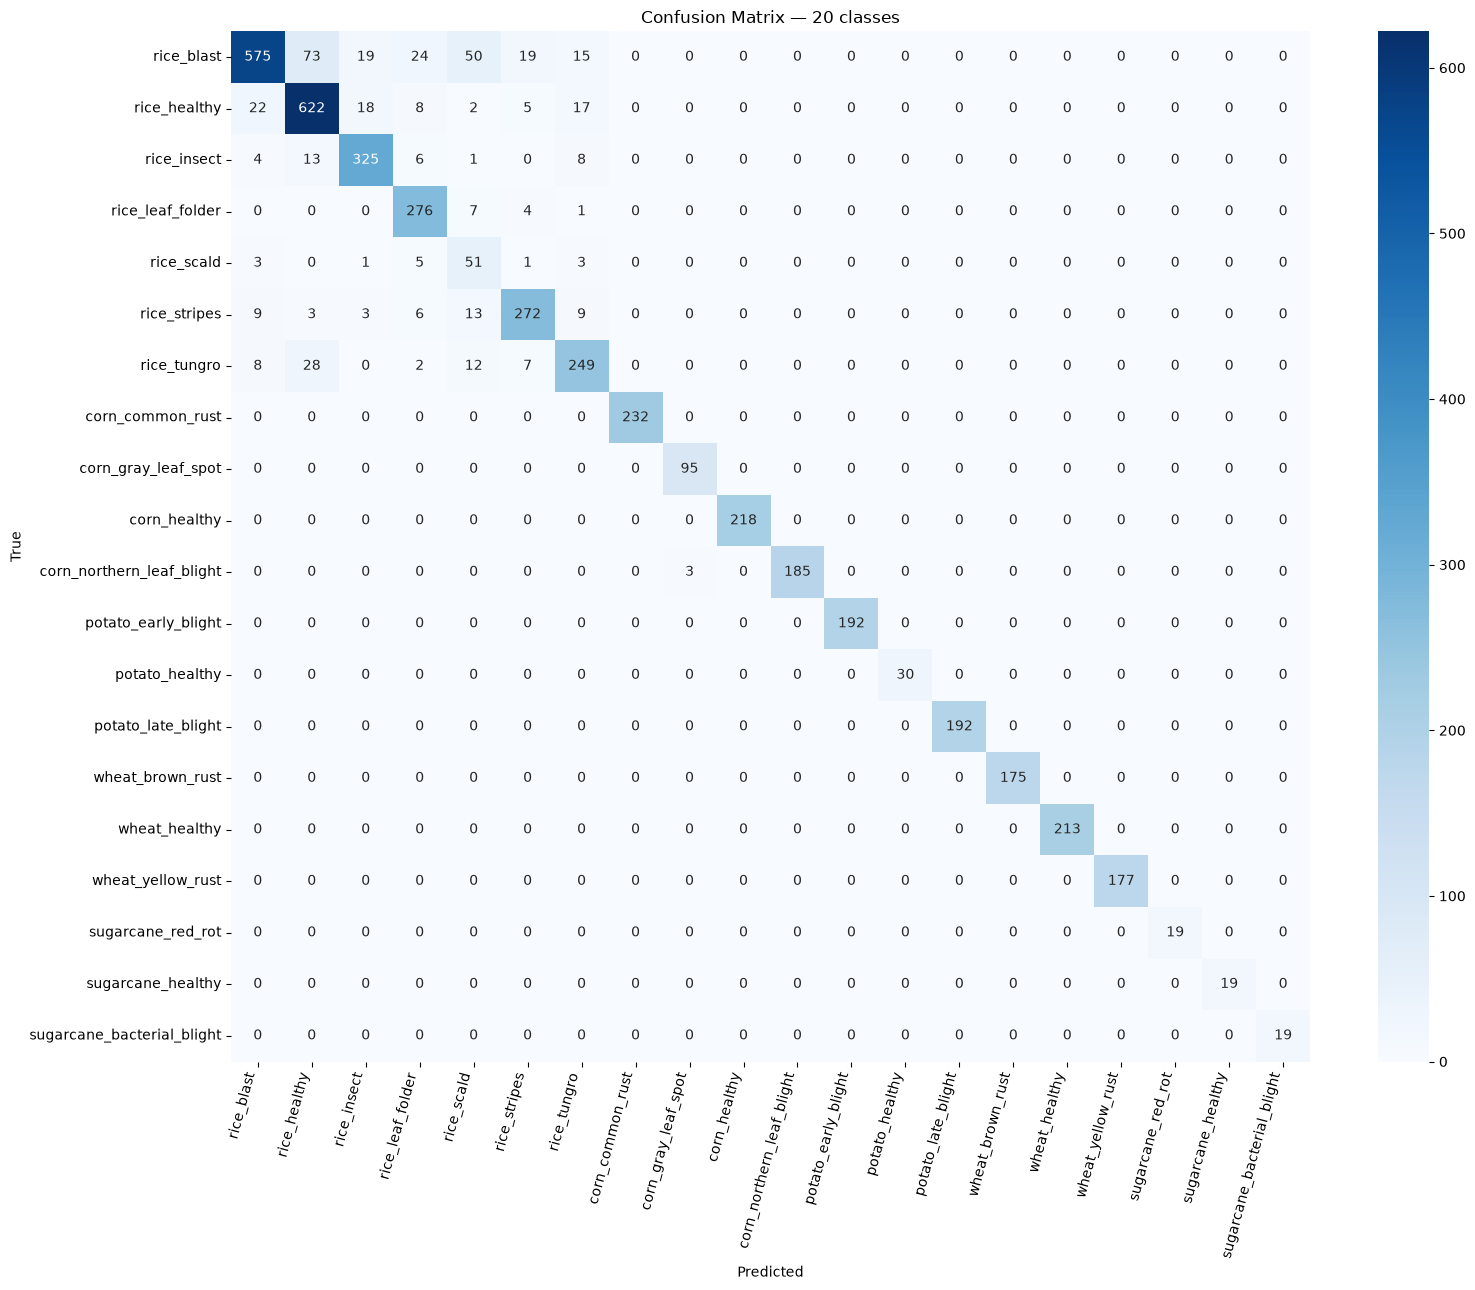

In [22]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — 20 classes")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()


## Step 17 — Severity thresholds & prevention knowledge base

In [23]:
SEVERITY_THRESHOLDS = {
    "rice_blast":       {"Low": 0.50, "Medium": 0.72},
    "rice_insect":      {"Low": 0.45, "Medium": 0.65},
    "rice_leaf_folder": {"Low": 0.45, "Medium": 0.65},
    "rice_scald":       {"Low": 0.48, "Medium": 0.68},
    "rice_stripes":     {"Low": 0.50, "Medium": 0.70},
    "rice_tungro":      {"Low": 0.50, "Medium": 0.72},
    "corn_common_rust":          {"Low": 0.50, "Medium": 0.72},
    "corn_gray_leaf_spot":       {"Low": 0.50, "Medium": 0.72},
    "corn_northern_leaf_blight": {"Low": 0.50, "Medium": 0.72},
    "potato_early_blight":       {"Low": 0.48, "Medium": 0.70},
    "potato_late_blight":        {"Low": 0.45, "Medium": 0.65},
    "wheat_brown_rust":          {"Low": 0.50, "Medium": 0.72},
    "wheat_yellow_rust":         {"Low": 0.48, "Medium": 0.70},
    "sugarcane_red_rot":         {"Low": 0.45, "Medium": 0.65},
    "sugarcane_bacterial_blight":{"Low": 0.48, "Medium": 0.70},
}

PREVENTION = {
    "rice_blast": ["Avoid excess nitrogen fertilizer", "Ensure adequate field drainage", "Monitor closely — spreads rapidly in wet weather"],
    "rice_insect": ["Use pheromone traps to monitor pest levels", "Introduce natural predators", "Apply targeted insecticide only if threshold exceeded"],
    "rice_leaf_folder": ["Avoid excess nitrogen", "Encourage natural enemies (spiders, wasps)", "Apply insecticide only if damage exceeds economic threshold"],
    "rice_scald": ["Improve field drainage", "Avoid leaf wetness at night through irrigation timing", "Use resistant varieties where available"],
    "rice_stripes": ["Control leafhopper vectors early", "Remove infected plants promptly", "Use virus-free planting material"],
    "rice_tungro": ["Control green leafhopper vector", "Use tungro-resistant varieties", "Remove and destroy infected plants early"],
    "corn_common_rust": ["Plant rust-resistant hybrids", "Apply fungicide at first sign of pustules", "Avoid dense planting to improve airflow"],
    "corn_gray_leaf_spot": ["Rotate crops away from corn residue", "Use resistant hybrids", "Apply fungicide during early tasseling if severe"],
    "corn_northern_leaf_blight": ["Rotate crops", "Till under crop residue", "Use resistant hybrids and fungicide if needed"],
    "potato_early_blight": ["Rotate crops (avoid consecutive potato/tomato)", "Remove infected foliage", "Apply protectant fungicide preventively"],
    "potato_late_blight": ["Act fast — this disease spreads very quickly", "Destroy infected plants immediately", "Apply systemic fungicide, ensure good drainage"],
    "wheat_brown_rust": ["Use resistant varieties", "Apply fungicide at flag leaf stage if detected early", "Avoid excess nitrogen"],
    "wheat_yellow_rust": ["Monitor fields closely in cool, wet seasons", "Apply fungicide promptly — spreads fast in favorable weather", "Use resistant cultivars"],
    "sugarcane_red_rot": ["Use disease-free setts for planting", "Avoid waterlogging", "Rotate with non-host crops, remove infected stalks"],
    "sugarcane_bacterial_blight": ["Use certified disease-free seed material", "Avoid overhead irrigation", "Remove and destroy infected plants"],
}

def get_prevention(disease):
    if disease.endswith("_healthy"):
        return ["No action needed — plant appears healthy.", "Continue routine monitoring."]
    return PREVENTION.get(disease, ["Consult a local agricultural extension officer for this disease."])


## Step 18 — Prediction function

In [24]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(image_path, show_plot=True):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)
    tensor = np.expand_dims(arr, axis=0)

    probs = model.predict(tensor, verbose=0)[0]
    class_idx = np.argmax(probs)
    disease = CLASS_NAMES[class_idx]
    confidence = float(probs[class_idx])

    crop, _, label = disease.partition("_")
    is_healthy = disease.endswith("_healthy")

    if not is_healthy:
        thresh = SEVERITY_THRESHOLDS.get(disease, {"Low": 0.5, "Medium": 0.7})
        if confidence < thresh["Low"]:
            severity = "Low"
        elif confidence < thresh["Medium"]:
            severity = "Medium"
        else:
            severity = "High"
    else:
        severity = "N/A"

    if show_plot:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{disease}  ({confidence*100:.1f}%)")
        plt.show()

    print(f"Crop       : {crop.capitalize()}")
    print(f"Diagnosis  : {disease.upper()}")
    if not is_healthy:
        print(f"Severity   : {severity}")
    print(f"Confidence : {confidence*100:.1f}%")
    print("\nPrevention / Action Steps:")
    for i, step in enumerate(get_prevention(disease), 1):
        print(f"  {i}. {step}")

    print("\nTop probabilities:")
    top5 = np.argsort(probs)[::-1][:5]
    for idx in top5:
        bar = "█" * int(probs[idx] * 30)
        print(f"  {CLASS_NAMES[idx]:<28} {probs[idx]*100:5.1f}%  {bar}")

    return disease, confidence



Actual class: RICE_BLAST


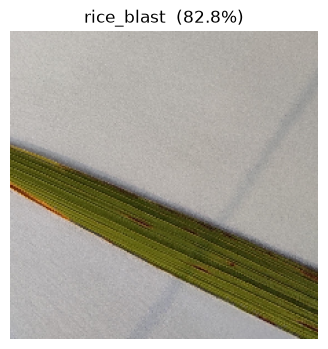

Crop       : Rice
Diagnosis  : RICE_BLAST
Severity   : High
Confidence : 82.8%

Prevention / Action Steps:
  1. Avoid excess nitrogen fertilizer
  2. Ensure adequate field drainage
  3. Monitor closely — spreads rapidly in wet weather

Top probabilities:
  rice_blast                    82.8%  ████████████████████████
  rice_healthy                  15.4%  ████
  rice_stripes                   1.7%  
  rice_tungro                    0.1%  
  rice_insect                    0.0%  

Actual class: RICE_HEALTHY


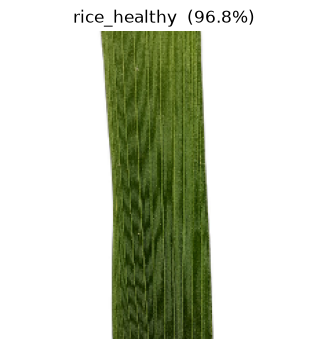

Crop       : Rice
Diagnosis  : RICE_HEALTHY
Confidence : 96.8%

Prevention / Action Steps:
  1. No action needed — plant appears healthy.
  2. Continue routine monitoring.

Top probabilities:
  rice_healthy                  96.8%  █████████████████████████████
  rice_blast                     1.8%  
  rice_tungro                    1.1%  
  rice_insect                    0.1%  
  rice_leaf_folder               0.0%  

Actual class: RICE_INSECT


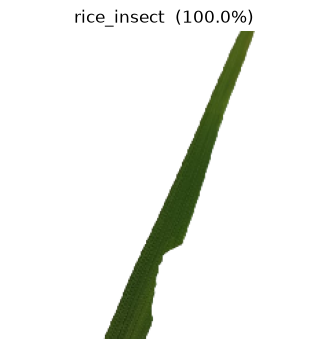

Crop       : Rice
Diagnosis  : RICE_INSECT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Use pheromone traps to monitor pest levels
  2. Introduce natural predators
  3. Apply targeted insecticide only if threshold exceeded

Top probabilities:
  rice_insect                  100.0%  █████████████████████████████
  rice_healthy                   0.0%  
  rice_blast                     0.0%  
  rice_stripes                   0.0%  
  rice_tungro                    0.0%  

Actual class: RICE_LEAF_FOLDER


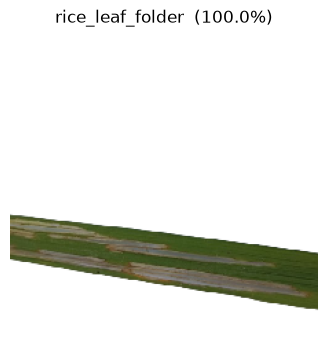

Crop       : Rice
Diagnosis  : RICE_LEAF_FOLDER
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Avoid excess nitrogen
  2. Encourage natural enemies (spiders, wasps)
  3. Apply insecticide only if damage exceeds economic threshold

Top probabilities:
  rice_leaf_folder             100.0%  █████████████████████████████
  rice_blast                     0.0%  
  rice_stripes                   0.0%  
  rice_scald                     0.0%  
  rice_insect                    0.0%  

Actual class: RICE_SCALD


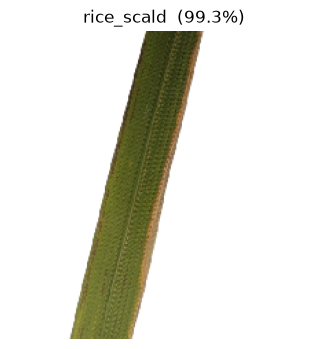

Crop       : Rice
Diagnosis  : RICE_SCALD
Severity   : High
Confidence : 99.3%

Prevention / Action Steps:
  1. Improve field drainage
  2. Avoid leaf wetness at night through irrigation timing
  3. Use resistant varieties where available

Top probabilities:
  rice_scald                    99.3%  █████████████████████████████
  rice_tungro                    0.6%  
  rice_blast                     0.0%  
  rice_insect                    0.0%  
  rice_healthy                   0.0%  

Actual class: RICE_STRIPES


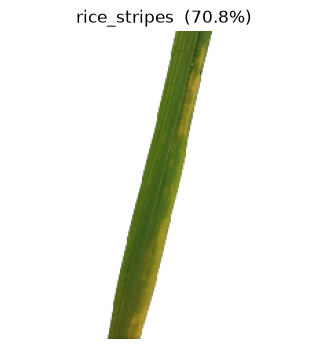

Crop       : Rice
Diagnosis  : RICE_STRIPES
Severity   : High
Confidence : 70.8%

Prevention / Action Steps:
  1. Control leafhopper vectors early
  2. Remove infected plants promptly
  3. Use virus-free planting material

Top probabilities:
  rice_stripes                  70.8%  █████████████████████
  rice_tungro                   28.2%  ████████
  rice_scald                     0.5%  
  rice_healthy                   0.3%  
  rice_blast                     0.2%  

Actual class: RICE_TUNGRO


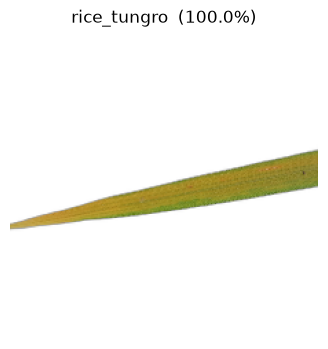

Crop       : Rice
Diagnosis  : RICE_TUNGRO
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Control green leafhopper vector
  2. Use tungro-resistant varieties
  3. Remove and destroy infected plants early

Top probabilities:
  rice_tungro                  100.0%  █████████████████████████████
  rice_healthy                   0.0%  
  rice_blast                     0.0%  
  rice_insect                    0.0%  
  rice_stripes                   0.0%  

Actual class: CORN_COMMON_RUST


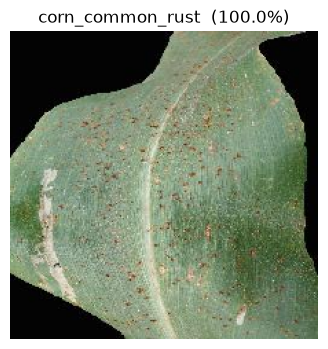

Crop       : Corn
Diagnosis  : CORN_COMMON_RUST
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Plant rust-resistant hybrids
  2. Apply fungicide at first sign of pustules
  3. Avoid dense planting to improve airflow

Top probabilities:
  corn_common_rust             100.0%  ██████████████████████████████
  rice_healthy                   0.0%  
  rice_blast                     0.0%  
  wheat_healthy                  0.0%  
  corn_gray_leaf_spot            0.0%  

Actual class: CORN_GRAY_LEAF_SPOT


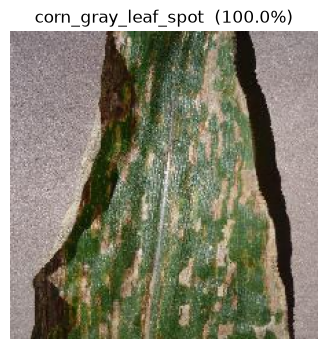

Crop       : Corn
Diagnosis  : CORN_GRAY_LEAF_SPOT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Rotate crops away from corn residue
  2. Use resistant hybrids
  3. Apply fungicide during early tasseling if severe

Top probabilities:
  corn_gray_leaf_spot          100.0%  ██████████████████████████████
  corn_northern_leaf_blight      0.0%  
  potato_early_blight            0.0%  
  potato_late_blight             0.0%  
  corn_common_rust               0.0%  

Actual class: CORN_HEALTHY


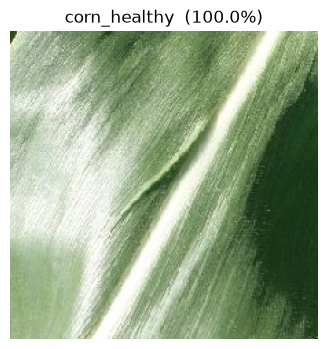

Crop       : Corn
Diagnosis  : CORN_HEALTHY
Confidence : 100.0%

Prevention / Action Steps:
  1. No action needed — plant appears healthy.
  2. Continue routine monitoring.

Top probabilities:
  corn_healthy                 100.0%  ██████████████████████████████
  corn_northern_leaf_blight      0.0%  
  rice_healthy                   0.0%  
  corn_gray_leaf_spot            0.0%  
  rice_insect                    0.0%  

Actual class: CORN_NORTHERN_LEAF_BLIGHT


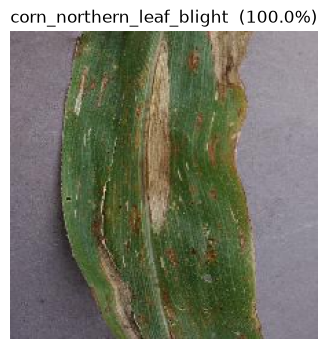

Crop       : Corn
Diagnosis  : CORN_NORTHERN_LEAF_BLIGHT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Rotate crops
  2. Till under crop residue
  3. Use resistant hybrids and fungicide if needed

Top probabilities:
  corn_northern_leaf_blight    100.0%  █████████████████████████████
  corn_gray_leaf_spot            0.0%  
  corn_common_rust               0.0%  
  rice_stripes                   0.0%  
  rice_scald                     0.0%  

Actual class: POTATO_EARLY_BLIGHT


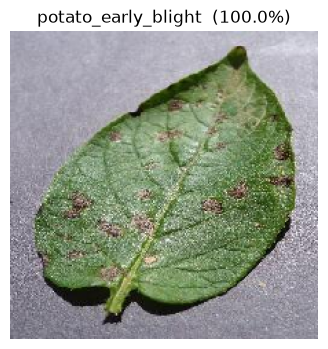

Crop       : Potato
Diagnosis  : POTATO_EARLY_BLIGHT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Rotate crops (avoid consecutive potato/tomato)
  2. Remove infected foliage
  3. Apply protectant fungicide preventively

Top probabilities:
  potato_early_blight          100.0%  ██████████████████████████████
  wheat_brown_rust               0.0%  
  rice_blast                     0.0%  
  potato_late_blight             0.0%  
  rice_healthy                   0.0%  

Actual class: POTATO_HEALTHY


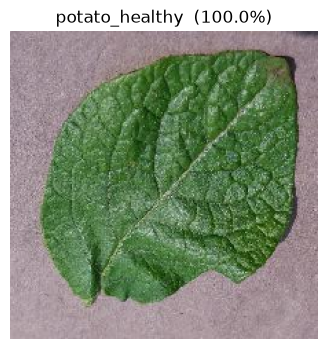

Crop       : Potato
Diagnosis  : POTATO_HEALTHY
Confidence : 100.0%

Prevention / Action Steps:
  1. No action needed — plant appears healthy.
  2. Continue routine monitoring.

Top probabilities:
  potato_healthy               100.0%  ██████████████████████████████
  potato_late_blight             0.0%  
  rice_insect                    0.0%  
  rice_healthy                   0.0%  
  corn_healthy                   0.0%  

Actual class: POTATO_LATE_BLIGHT


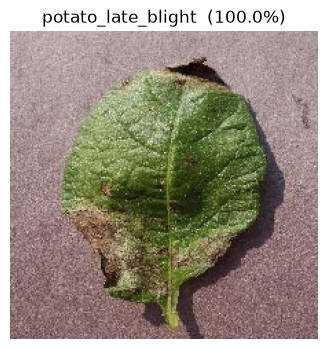

Crop       : Potato
Diagnosis  : POTATO_LATE_BLIGHT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Act fast — this disease spreads very quickly
  2. Destroy infected plants immediately
  3. Apply systemic fungicide, ensure good drainage

Top probabilities:
  potato_late_blight           100.0%  ██████████████████████████████
  corn_northern_leaf_blight      0.0%  
  potato_early_blight            0.0%  
  rice_blast                     0.0%  
  rice_insect                    0.0%  

Actual class: WHEAT_BROWN_RUST


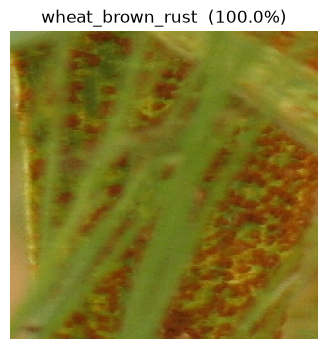

Crop       : Wheat
Diagnosis  : WHEAT_BROWN_RUST
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Use resistant varieties
  2. Apply fungicide at flag leaf stage if detected early
  3. Avoid excess nitrogen

Top probabilities:
  wheat_brown_rust             100.0%  ██████████████████████████████
  wheat_healthy                  0.0%  
  corn_northern_leaf_blight      0.0%  
  wheat_yellow_rust              0.0%  
  rice_stripes                   0.0%  

Actual class: WHEAT_HEALTHY


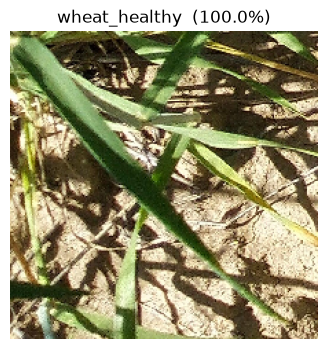

Crop       : Wheat
Diagnosis  : WHEAT_HEALTHY
Confidence : 100.0%

Prevention / Action Steps:
  1. No action needed — plant appears healthy.
  2. Continue routine monitoring.

Top probabilities:
  wheat_healthy                100.0%  ██████████████████████████████
  rice_healthy                   0.0%  
  wheat_brown_rust               0.0%  
  rice_leaf_folder               0.0%  
  potato_late_blight             0.0%  

Actual class: WHEAT_YELLOW_RUST


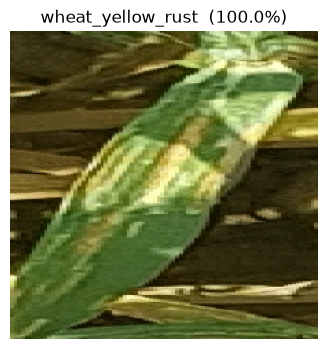

Crop       : Wheat
Diagnosis  : WHEAT_YELLOW_RUST
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Monitor fields closely in cool, wet seasons
  2. Apply fungicide promptly — spreads fast in favorable weather
  3. Use resistant cultivars

Top probabilities:
  wheat_yellow_rust            100.0%  ██████████████████████████████
  wheat_healthy                  0.0%  
  wheat_brown_rust               0.0%  
  rice_stripes                   0.0%  
  rice_healthy                   0.0%  

Actual class: SUGARCANE_RED_ROT


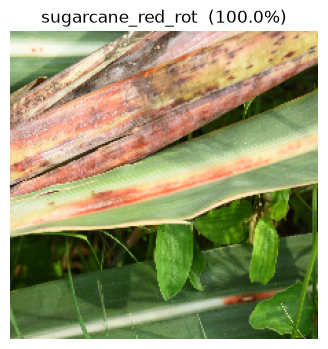

Crop       : Sugarcane
Diagnosis  : SUGARCANE_RED_ROT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Use disease-free setts for planting
  2. Avoid waterlogging
  3. Rotate with non-host crops, remove infected stalks

Top probabilities:
  sugarcane_red_rot            100.0%  ██████████████████████████████
  sugarcane_bacterial_blight     0.0%  
  wheat_brown_rust               0.0%  
  sugarcane_healthy              0.0%  
  rice_stripes                   0.0%  

Actual class: SUGARCANE_HEALTHY


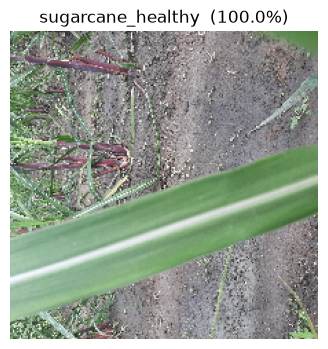

Crop       : Sugarcane
Diagnosis  : SUGARCANE_HEALTHY
Confidence : 100.0%

Prevention / Action Steps:
  1. No action needed — plant appears healthy.
  2. Continue routine monitoring.

Top probabilities:
  sugarcane_healthy            100.0%  ██████████████████████████████
  wheat_healthy                  0.0%  
  sugarcane_red_rot              0.0%  
  rice_healthy                   0.0%  
  rice_stripes                   0.0%  

Actual class: SUGARCANE_BACTERIAL_BLIGHT


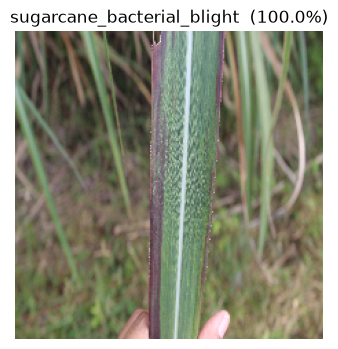

Crop       : Sugarcane
Diagnosis  : SUGARCANE_BACTERIAL_BLIGHT
Severity   : High
Confidence : 100.0%

Prevention / Action Steps:
  1. Use certified disease-free seed material
  2. Avoid overhead irrigation
  3. Remove and destroy infected plants

Top probabilities:
  sugarcane_bacterial_blight   100.0%  ██████████████████████████████
  sugarcane_red_rot              0.0%  
  sugarcane_healthy              0.0%  
  rice_blast                     0.0%  
  rice_healthy                   0.0%  


In [25]:
# Quick sanity test — one image per class from the test set
for cls in CLASS_NAMES:
    cls_dir = DATASET_ROOT / "test" / cls
    imgs = list_images(cls_dir)
    if imgs:
        print(f"\n{'='*60}\nActual class: {cls.upper()}\n{'='*60}")
        predict_image(str(imgs[0]))


## Step 19 — Explainable AI: Grad-CAM
Shows which region of the leaf drove the model's prediction — builds trust and helps
catch cases where the model is keying off background rather than the actual lesion.

In [26]:
import matplotlib.cm as cm

# Confirm this matches your model — EfficientNetB3's last conv layer is normally "top_conv"
LAST_CONV_LAYER = "top_conv"
assert LAST_CONV_LAYER in [l.name for l in model.layers], \
    f"Layer not found. Available conv-like layers: {[l.name for l in model.layers if 'conv' in l.name.lower()][-5:]}"

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(image_path, model, last_conv_layer_name=LAST_CONV_LAYER, alpha=0.4):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)
    img_array = np.expand_dims(arr, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_index = np.argmax(probs)
    disease = CLASS_NAMES[pred_index]
    confidence = float(probs[pred_index])

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index)
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((IMG_SIZE, IMG_SIZE))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + arr
    superimposed = tf.keras.preprocessing.image.array_to_img(superimposed)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(superimposed); axes[1].set_title(f"Grad-CAM: {disease} ({confidence*100:.1f}%)"); axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    return disease, confidence


In [27]:
# Run Grad-CAM on one test image per class
for cls in CLASS_NAMES:
    cls_dir = DATASET_ROOT / "test" / cls
    imgs = list_images(cls_dir)
    if imgs:
        print(f"\nTrue class: {cls}")
        overlay_gradcam(str(imgs[0]), model)



True class: rice_blast


c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

## Notes
- **Retraining, not resuming**: this notebook trains from scratch (Phase 1→3) rather than
  loading your old rice-only checkpoint — the old model's output layer had 7 classes,
  the new one has 20, so weights aren't compatible at that layer.
- **If GPU memory runs out** on `BATCH_SIZE = 32`, drop to 16.
- **If a `find_folder()` assertion fails**, uncomment `print_tree(RAW_NEW)` in Step 4 to see
  the actual extracted structure and adjust the target folder names.
- **To reuse this on new photos later**: call `predict_image(path)` for a text report or
  `overlay_gradcam(path, model)` for the visual explanation.
